#Semantic Role Labeling(SRL)

copyright 2022, Denis Rothman, MIT License.

**March 2023 update**: The AllenNLP modules in this notebook do not run on Google Colab anymore. One or both of the platforms may have updated their
librairies in a conflicting configuration.

Please use [the NEW SRL Notebook, Semantic_Role_Labeling_wit_ChatGPT](https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/blob/main/Chapter10/Semantic_Role_Labeling_with_ChatGPT.ipynb)

________________________________________________________________________________________

The notebook is an implementation of the Allen Institute for AI BERT-based model. [Reference usage of the Notebook](https://demo.allennlp.org/semantic-role-labeling/MjE4NjI1Ng==)


The BERT-based model is an implementation of [Peng Shi and Jimmy Lin, (2019), ‘Simple BERT Models for Relation Extraction and Semantic Role Labeling’]( https://arxiv.org/abs/1904.05255)


Intalling Allen NLP

#SRL experiments with the BERT-based model

In [1]:
from IPython.display import Image     #This is used for rendering images in the notebook

In [ ]:
!pip install allennlp==2.1.0 allennlp-models==2.1.0

     |████████████████████████████████| 585 kB 4.8 MB/s 
     |████████████████████████████████| 407 kB 50.7 MB/s 
     |████████████████████████████████| 1.2 MB 40.2 MB/s 
     |████████████████████████████████| 592 kB 45.9 MB/s 
     |████████████████████████████████| 1.9 MB 23.0 MB/s 
     |████████████████████████████████| 131 kB 65.7 MB/s 
     |████████████████████████████████| 12.8 MB 9.8 MB/s 
     |████████████████████████████████| 124 kB 74.9 MB/s 
     |████████████████████████████████| 776.8 MB 16 kB/s 
     |████████████████████████████████| 56 kB 4.3 MB/s 
     |████████████████████████████████| 64 kB 2.5 MB/s 
     |████████████████████████████████| 79 kB 7.0 MB/s 
     |████████████████████████████████| 8.5 MB 53.4 MB/s 
     |████████████████████████████████| 138 kB 62.6 MB/s 
     |████████████████████████████████| 127 kB 48.8 MB/s 
     |████████████████████████████████| 895 kB 50.7 MB/s 
     |████████████████████████████████| 3.3 MB 51.9 MB/s 
  Created wheel for o

Importing the tagging predictor

In [ ]:
from allennlp.predictors.predictor import Predictor
import allennlp_models.tagging
import json

predictor = Predictor.from_path("https://storage.googleapis.com/allennlp-public-models/structured-prediction-srl-bert.2020.12.15.tar.gz")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet.zip.


Plugin allennlp_models could not be loaded: No module named 'nltk.translate.meteor_score'
downloading: 100%|##########| 405972254/405972254 [00:08<00:00, 48381445.74B/s]


Downloading:   0%|          | 0.00/570 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/232k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/466k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/440M [00:00<?, ?B/s]

Defining two display options

In [ ]:
def head(prediction):
  # Iterating through the json to display excerpt of the prediciton
  for i in prediction['verbs']:
    print('Verb:',i['verb'],i['description'])

In [ ]:
def full(prediction):
  #print the full prediction
  print(json.dumps(prediction, indent = 1, sort_keys=True))

#Basic samples

Sample 1: Did Bob really think he could prepare a meal for 50 people in only a few hours?

In [ ]:
prediction=predictor.predict(
    sentence="Did Bob really think he could prepare a meal for 50 people in only a few hours?"
)
head(prediction)

Verb: Did [V: Did] Bob really think he could prepare a meal for 50 people in only a few hours ?
Verb: think Did [ARG0: Bob] [ARGM-ADV: really] [V: think] [ARG1: he could prepare a meal for 50 people in only a few hours] ?
Verb: could Did Bob really think he [V: could] [ARG1: prepare a meal for 50 people in only a few hours] ?
Verb: prepare Did Bob really think [ARG0: he] [ARGM-MOD: could] [V: prepare] [ARG1: a meal for 50 people] [ARGM-TMP: in only a few hours] ?


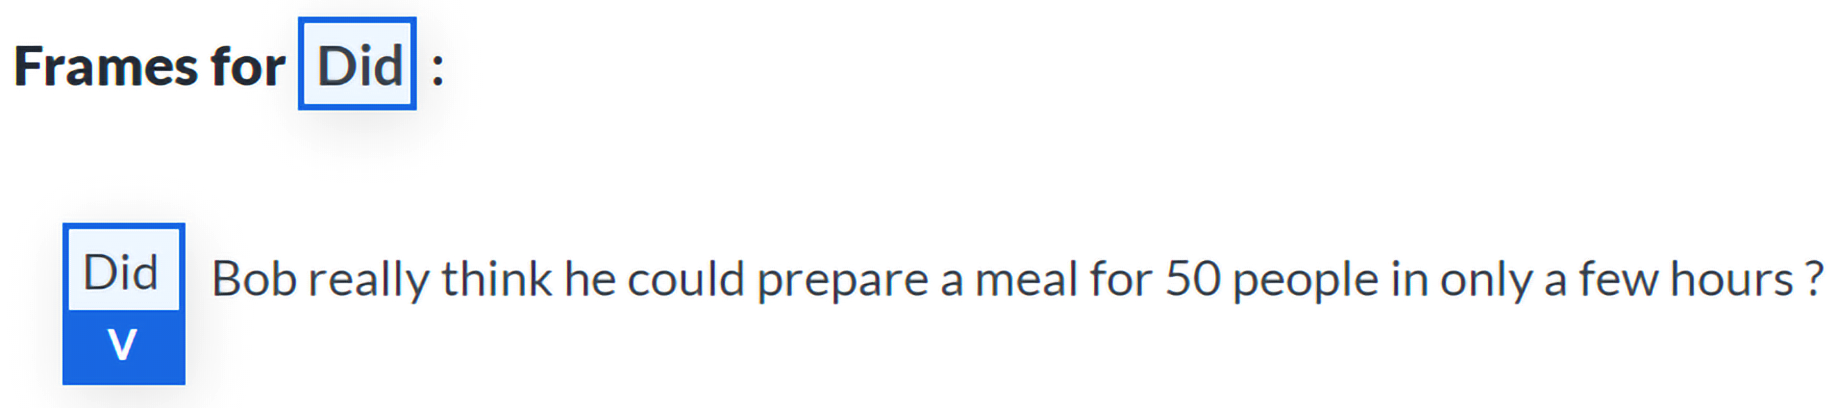

In [3]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_02.png', width=800) #This is used for rendering images in the notebook

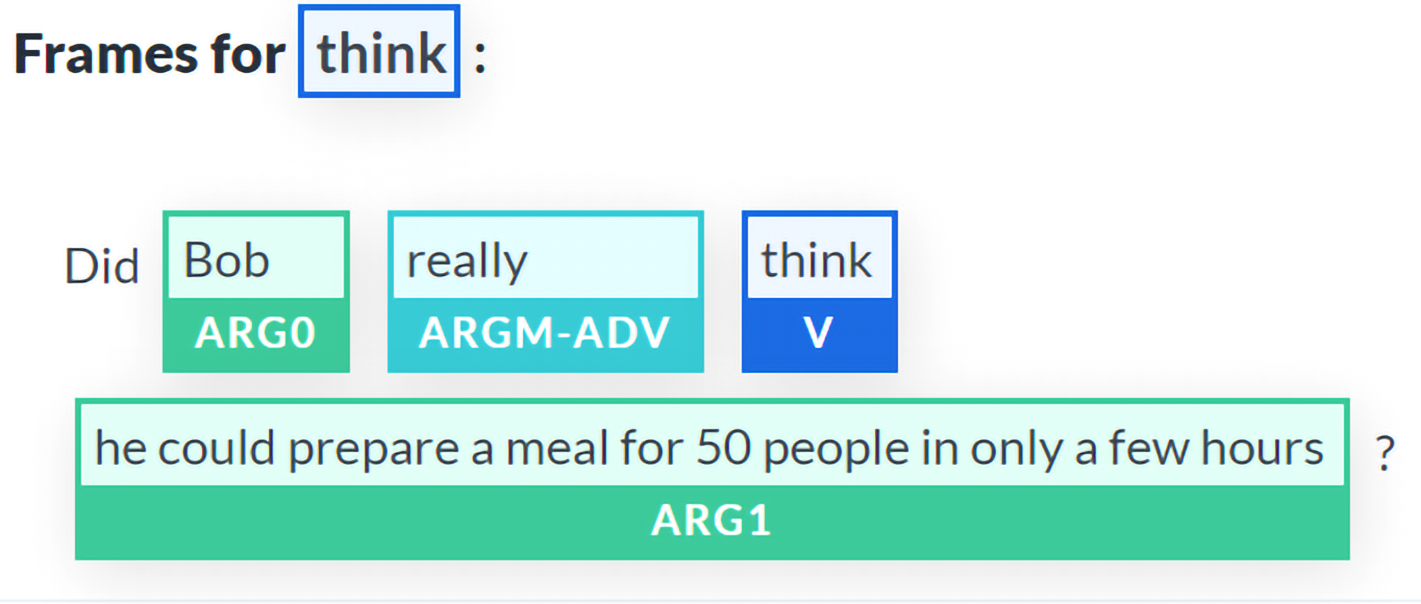

In [4]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_03.png', width=800) #This is used for rendering images in the notebook

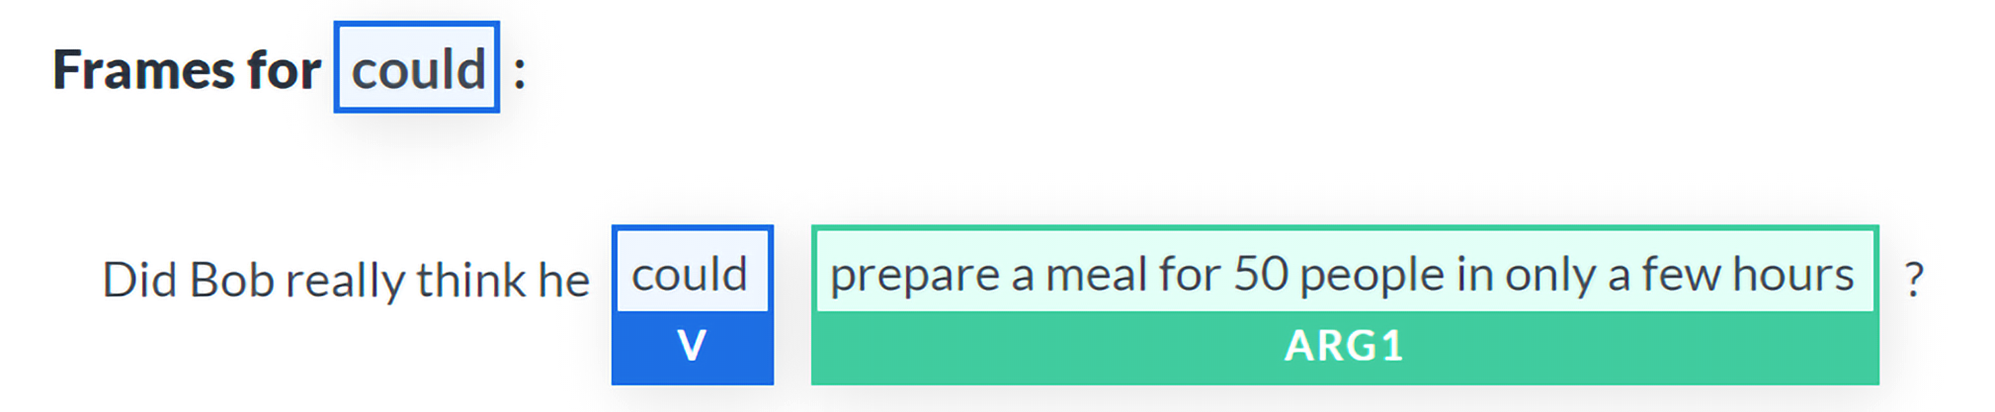

In [5]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_04.png', width=800) #This is used for rendering images in the notebook

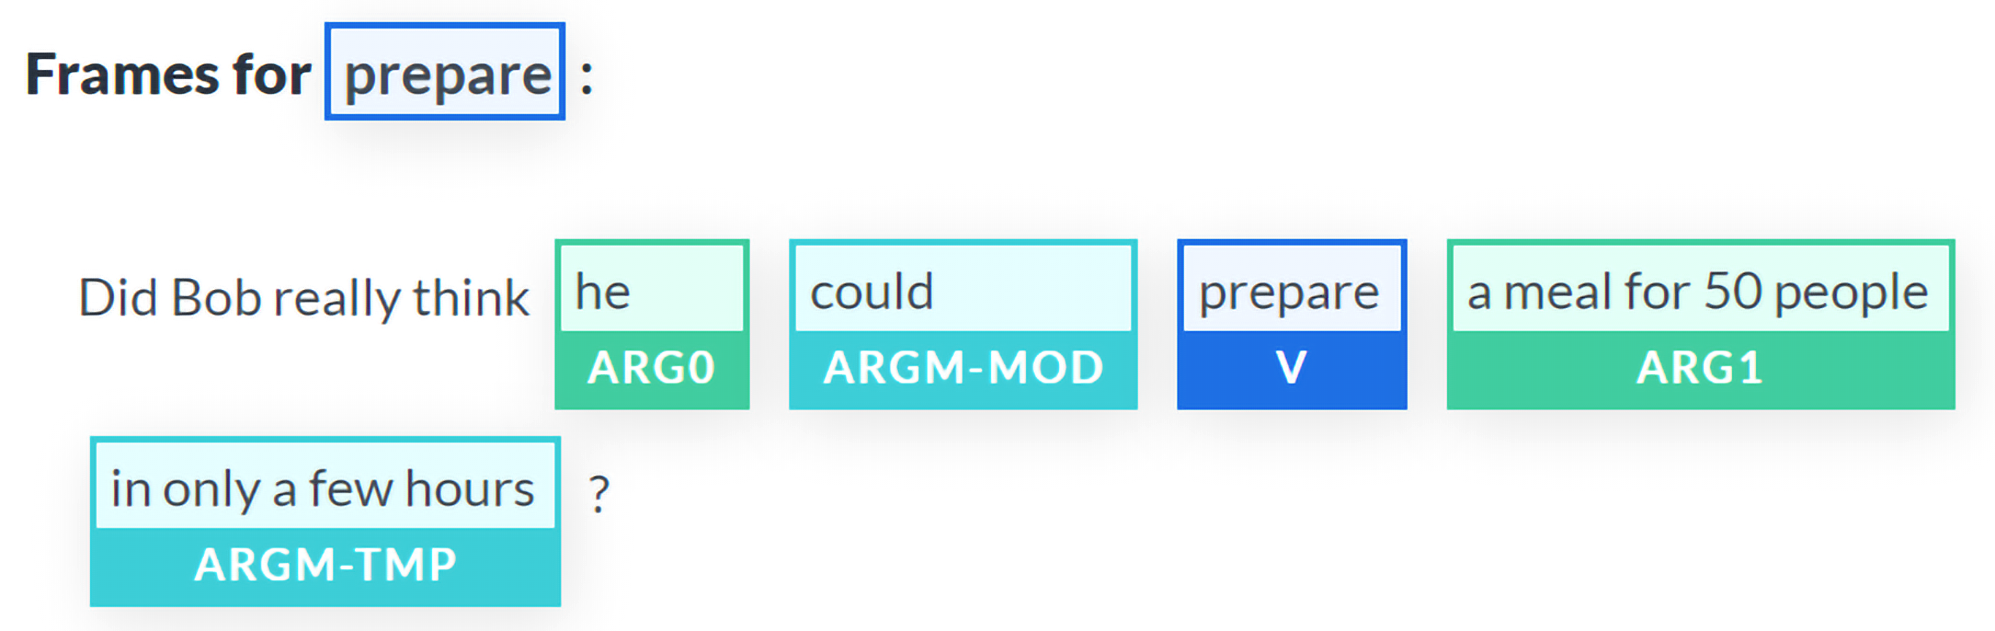

In [6]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_05.png', width=800) #This is used for rendering images in the notebook

In [ ]:
full(prediction)

{
 "verbs": [
  {
   "description": "[V: Did] Bob really think he could prepare a meal for 50 people in only a few hours ?",
   "tags": [
    "B-V",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O"
   ],
   "verb": "Did"
  },
  {
   "description": "Did [ARG0: Bob] [ARGM-ADV: really] [V: think] [ARG1: he could prepare a meal for 50 people in only a few hours] ?",
   "tags": [
    "O",
    "B-ARG0",
    "B-ARGM-ADV",
    "B-V",
    "B-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "O"
   ],
   "verb": "think"
  },
  {
   "description": "Did Bob really think he [V: could] [ARG1: prepare a meal for 50 people in only a few hours] ?",
   "tags": [
    "O",
    "O",
    "O",
    "O",
    "O",
    "B-V",
    "B-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
   

Sample 2: Mrs. and Mr. Tomaso went to Europe for vacation and visited Paris and first went to visit the Eiffel Tower.

In [ ]:
prediction=predictor.predict(
    sentence="Mrs. and Mr. Tomaso went to Europe for vacation and visited Paris and first went to visit the Eiffel Tower."
)
head(prediction)

Verb: went [ARG0: Mrs. and Mr. Tomaso] [V: went] [ARG4: to Europe] [ARGM-PRP: for vacation] and visited Paris and first went to visit the Eiffel Tower .
Verb: visited [ARG0: Mrs. and Mr. Tomaso] went to Europe for vacation and [V: visited] [ARG1: Paris] and first went to visit the Eiffel Tower .
Verb: went [ARG0: Mrs. and Mr. Tomaso] went to Europe for vacation and visited Paris and [ARGM-TMP: first] [V: went] [ARG1: to visit the Eiffel Tower] .
Verb: visit [ARG0: Mrs. and Mr. Tomaso] went to Europe for vacation and visited Paris and first went to [V: visit] [ARG1: the Eiffel Tower] .


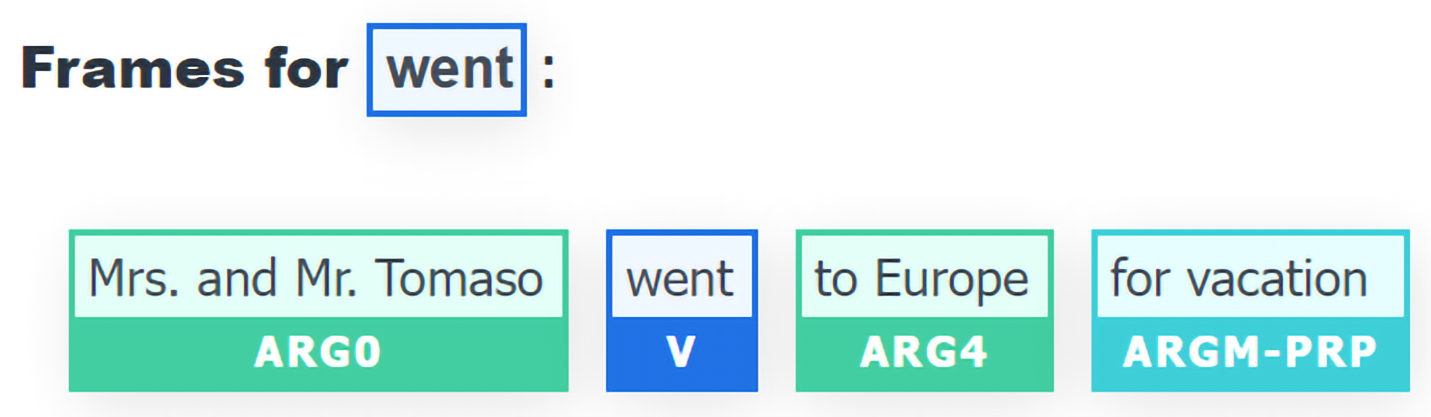

In [8]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_06.png', width=800) #This is used for rendering images in the notebook

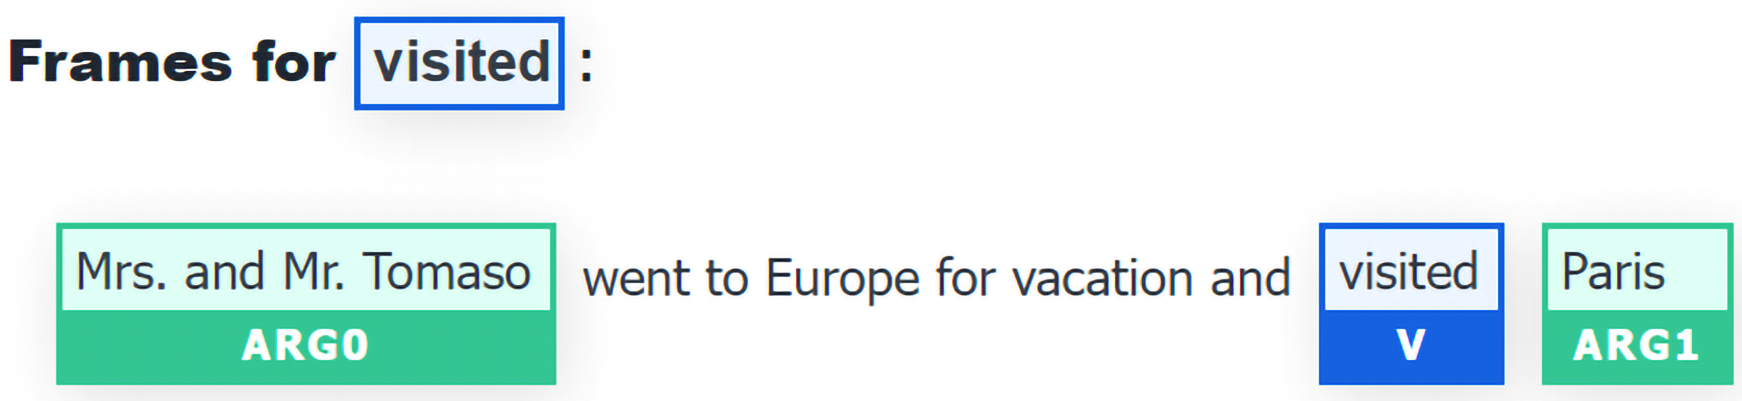

In [9]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_07.png', width=800) #This is used for rendering images in the notebook

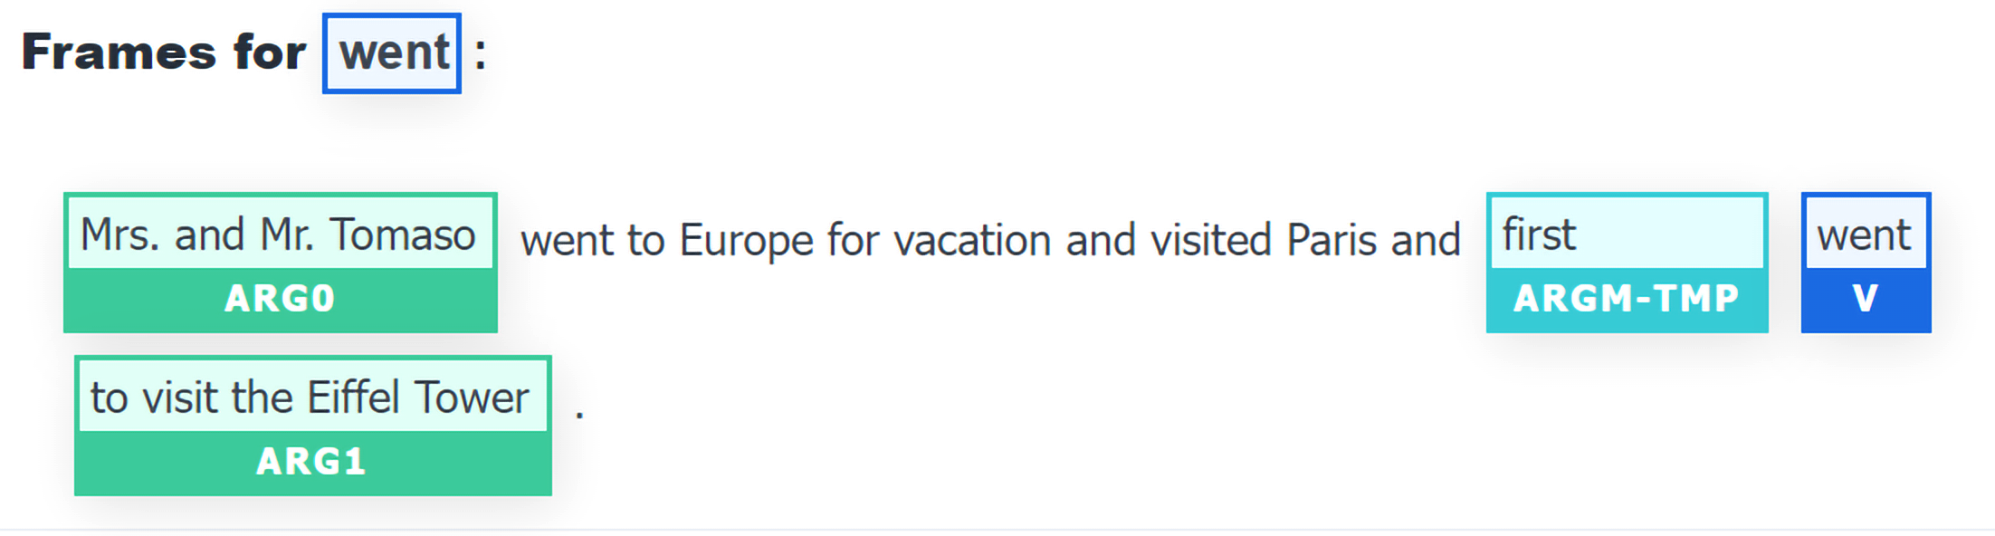

In [12]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_08.png', width=800) #This is used for rendering images in the notebook

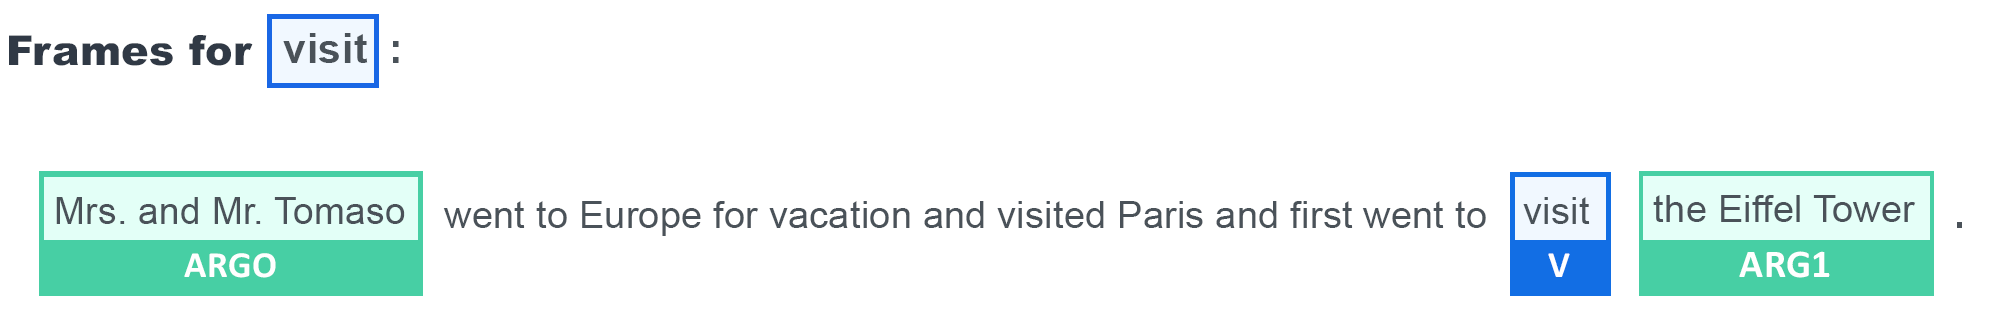

In [13]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_09.png', width=800) #This is used for rendering images in the notebook

In [ ]:
full(prediction)

{
 "verbs": [
  {
   "description": "[ARG0: Mrs. and Mr. Tomaso] [V: went] [ARG4: to Europe] [ARGM-PRP: for vacation] and visited Paris and first went to visit the Eiffel Tower .",
   "tags": [
    "B-ARG0",
    "I-ARG0",
    "I-ARG0",
    "I-ARG0",
    "B-V",
    "B-ARG4",
    "I-ARG4",
    "B-ARGM-PRP",
    "I-ARGM-PRP",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O"
   ],
   "verb": "went"
  },
  {
   "description": "[ARG0: Mrs. and Mr. Tomaso] went to Europe for vacation and [V: visited] [ARG1: Paris] and first went to visit the Eiffel Tower .",
   "tags": [
    "B-ARG0",
    "I-ARG0",
    "I-ARG0",
    "I-ARG0",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "B-V",
    "B-ARG1",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O"
   ],
   "verb": "visited"
  },
  {
   "description": "[ARG0: Mrs. and Mr. Tomaso] went to Europe for vacation and visited Paris and [ARGM-TMP: first] [V: w

Sample 3:John wanted to drink tea, Mary likes to drink coffee but Karim drank some cool water and Faiza would like to drink tomato juice.

In [ ]:
prediction=predictor.predict(
    sentence="John wanted to drink tea, Mary likes to drink coffee but Karim drank some cool water and Faiza would like to drink tomato juice."
)
head(prediction)

Verb: wanted [ARG0: John] [V: wanted] [ARG1: to drink tea] , Mary likes to drink coffee but Karim drank some cool water and Faiza would like to drink tomato juice .
Verb: drink [ARG0: John] wanted to [V: drink] [ARG1: tea] , Mary likes to drink coffee but Karim drank some cool water and Faiza would like to drink tomato juice .
Verb: likes John wanted to drink tea , [ARG0: Mary] [V: likes] [ARG1: to drink coffee] but Karim drank some cool water and Faiza would like to drink tomato juice .
Verb: drink John wanted to drink tea , [ARG0: Mary] likes to [V: drink] [ARG1: coffee] but Karim drank some cool water and Faiza would like to drink tomato juice .
Verb: drank John wanted to drink tea , Mary likes to drink coffee but [ARG0: Karim] [V: drank] [ARG1: some cool water] and Faiza would like to drink tomato juice .
Verb: would John wanted to drink tea , Mary likes to drink coffee but Karim drank some cool water and [ARG0: Faiza] [V: would] like [ARG1: to drink tomato juice] .
Verb: like John

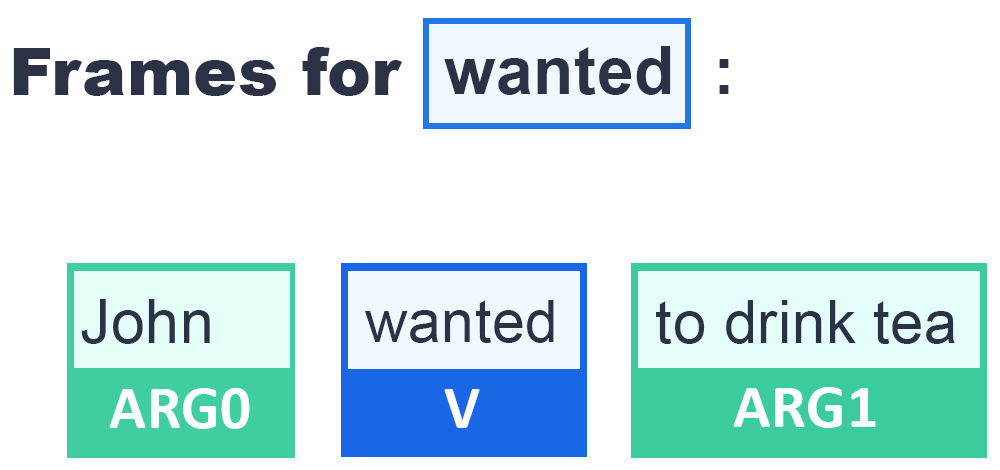

In [15]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_10.png', width=800) #This is used for rendering images in the notebook

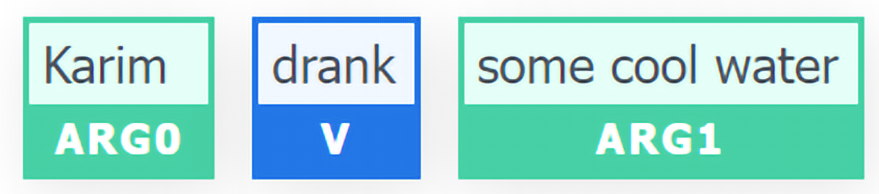

In [16]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_11.png', width=800) #This is used for rendering images in the notebook

In [ ]:
full(prediction)

{
 "verbs": [
  {
   "description": "[ARG0: John] [V: wanted] [ARG1: to drink tea] , Mary likes to drink coffee but Karim drank some cool water and Faiza would like to drink tomato juice .",
   "tags": [
    "B-ARG0",
    "B-V",
    "B-ARG1",
    "I-ARG1",
    "I-ARG1",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O"
   ],
   "verb": "wanted"
  },
  {
   "description": "[ARG0: John] wanted to [V: drink] [ARG1: tea] , Mary likes to drink coffee but Karim drank some cool water and Faiza would like to drink tomato juice .",
   "tags": [
    "B-ARG0",
    "O",
    "O",
    "B-V",
    "B-ARG1",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O"
   ],
   "verb": "drink"
  },
  {
   "description": "John wanted to drink t

#Difficult samples

Sample 4: Alice, whose husband went jogging every Sunday, liked to go to a dancing class in the meantime.

In [ ]:
prediction=predictor.predict(
    sentence="Alice, whose husband went jogging every Sunday, liked to go to a dancing class in the meantime."
)
head(prediction)

Verb: went Alice , [ARG0: whose husband] [V: went] [ARG1: jogging] [ARGM-TMP: every Sunday] , liked to go to a dancing class in the meantime .
Verb: jogging Alice , [ARG0: whose husband] went [V: jogging] [ARGM-TMP: every Sunday] , liked to go to a dancing class in the meantime .
Verb: liked [ARG0: Alice , whose husband went jogging every Sunday] , [V: liked] [ARG1: to go to a dancing class in the meantime] .
Verb: go [ARG0: Alice , whose husband went jogging every Sunday] , liked to [V: go] [ARG4: to a dancing class] [ARGM-TMP: in the meantime] .
Verb: dancing Alice , whose husband went jogging every Sunday , liked to go to a [V: dancing] class in the meantime .


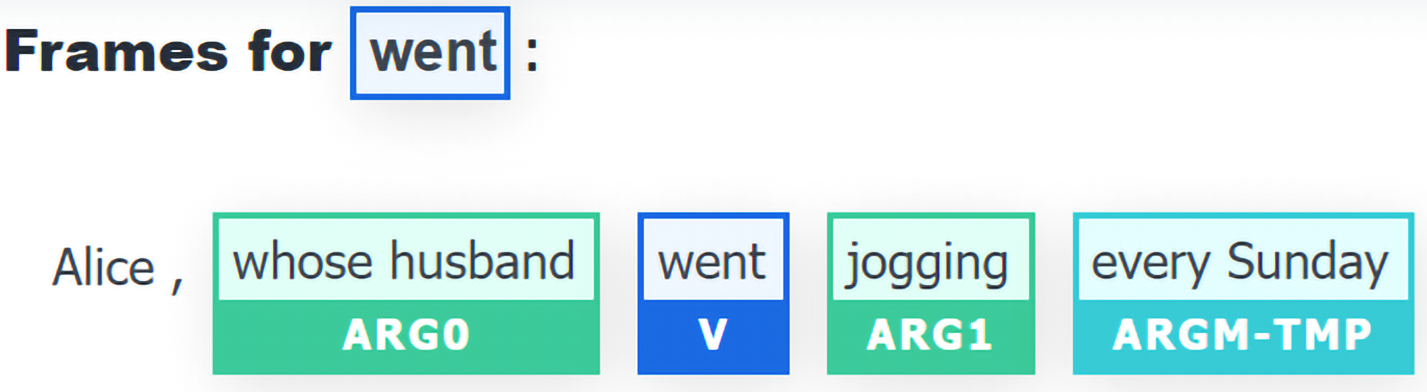

In [17]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_12.png', width=800) #This is used for rendering images in the notebook

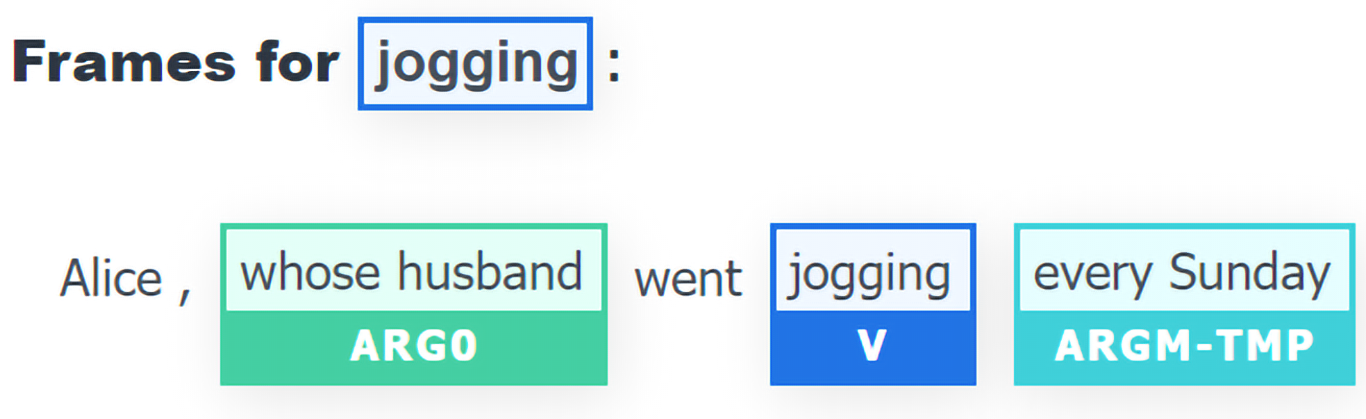

In [18]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_13.png', width=800) #This is used for rendering images in the notebook

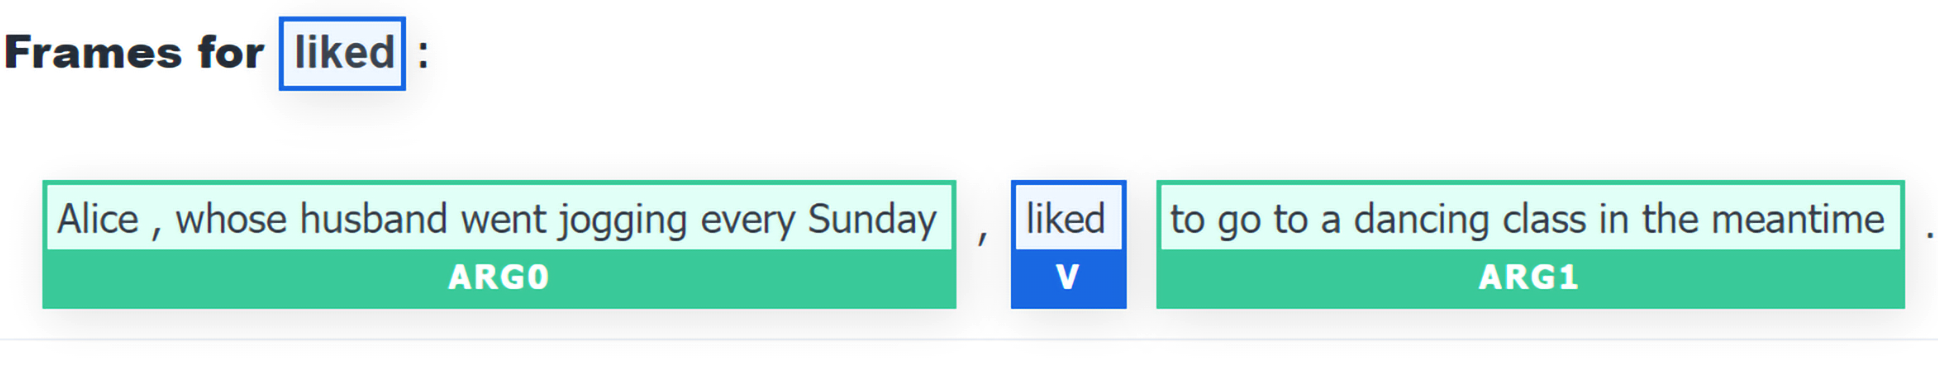

In [19]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_14.png', width=800) #This is used for rendering images in the notebook

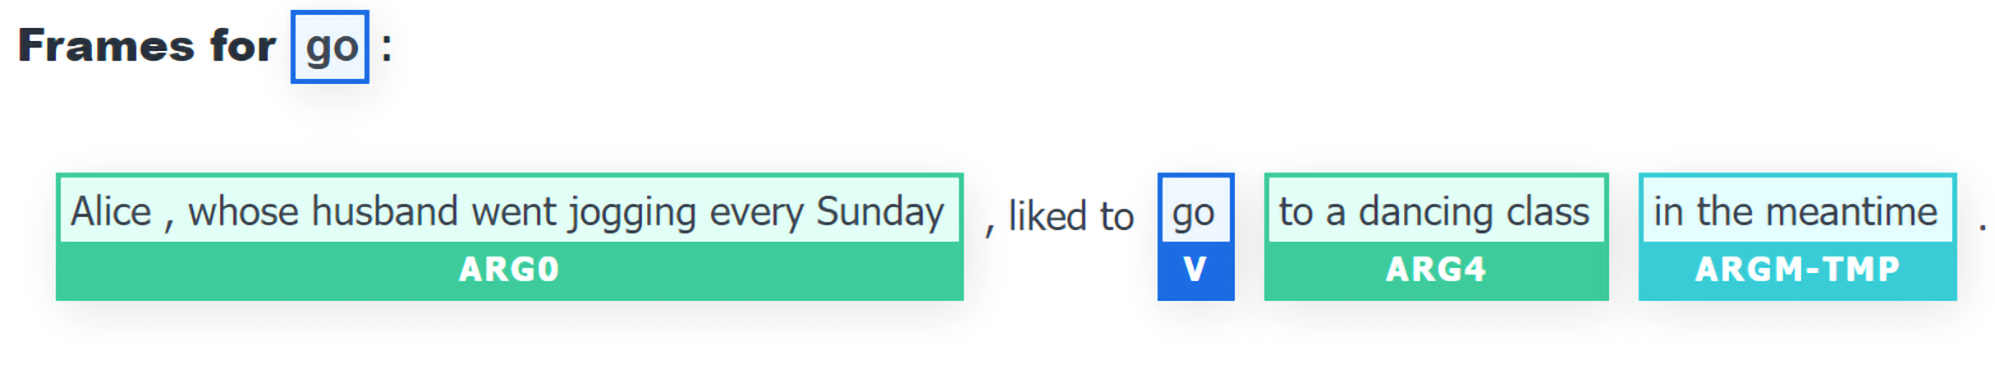

In [20]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_15.png', width=800) #This is used for rendering images in the notebook

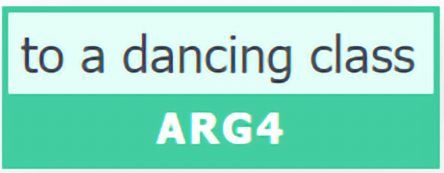

In [22]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_16.png', width=400) #This is used for rendering images in the notebook

In [ ]:
full(prediction)

{
 "verbs": [
  {
   "description": "Alice , [ARG0: whose husband] [V: went] [ARG1: jogging] [ARGM-TMP: every Sunday] , liked to go to a dancing class in the meantime .",
   "tags": [
    "O",
    "O",
    "B-ARG0",
    "I-ARG0",
    "B-V",
    "B-ARG1",
    "B-ARGM-TMP",
    "I-ARGM-TMP",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O"
   ],
   "verb": "went"
  },
  {
   "description": "Alice , [ARG0: whose husband] went [V: jogging] [ARGM-TMP: every Sunday] , liked to go to a dancing class in the meantime .",
   "tags": [
    "O",
    "O",
    "B-ARG0",
    "I-ARG0",
    "O",
    "B-V",
    "B-ARGM-TMP",
    "I-ARGM-TMP",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O",
    "O"
   ],
   "verb": "jogging"
  },
  {
   "description": "[ARG0: Alice , whose husband went jogging every Sunday] , [V: liked] [ARG1: to go to a dancing class in the meantime] .",
   "tags": [
    "B-ARG0"

Sample 5: The bright sun, the blue sky, the warm sand, the palm trees, everything round off.

In [ ]:
prediction=predictor.predict(
    sentence="The bright sun, the blue sky, the warm sand, the palm trees, everything round off."
)
head(prediction)

In [ ]:
full(prediction)

{
 "verbs": [],
 "words": [
  "The",
  "bright",
  "sun",
  ",",
  "the",
  "blue",
  "sky",
  ",",
  "the",
  "warm",
  "sand",
  ",",
  "the",
  "palm",
  "trees",
  ",",
  "everything",
  "round",
  "off",
  "."
 ]
}


In [ ]:
prediction=predictor.predict(
    sentence="The bright sun, the blue sky, the warm sand, the palm trees, everything rounds off."
)
head(prediction)

Verb: rounds [ARG1: The bright sun , the blue sky , the warm sand , the palm trees , everything] [V: rounds] [ARGM-PRD: off] .


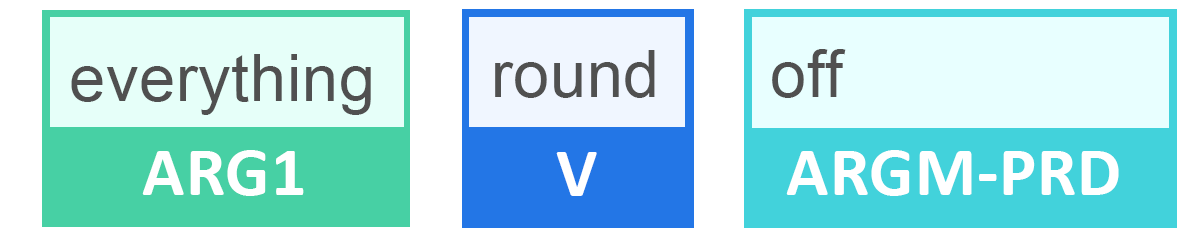

In [23]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_17.png', width=800) #This is used for rendering images in the notebook

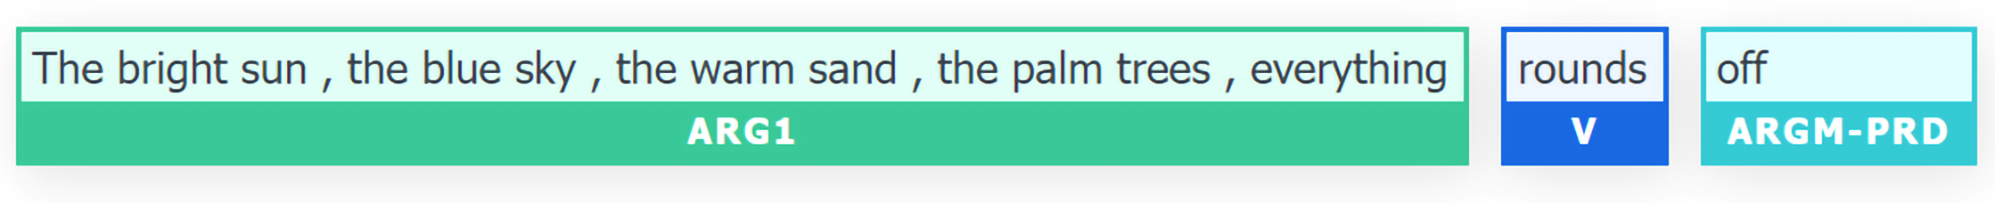

In [24]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_18.png', width=800) #This is used for rendering images in the notebook

In [ ]:
full(prediction)

{
 "verbs": [
  {
   "description": "[ARG1: The bright sun , the blue sky , the warm sand , the palm trees , everything] [V: rounds] [ARGM-PRD: off] .",
   "tags": [
    "B-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "I-ARG1",
    "B-V",
    "B-ARGM-PRD",
    "O"
   ],
   "verb": "rounds"
  }
 ],
 "words": [
  "The",
  "bright",
  "sun",
  ",",
  "the",
  "blue",
  "sky",
  ",",
  "the",
  "warm",
  "sand",
  ",",
  "the",
  "palm",
  "trees",
  ",",
  "everything",
  "rounds",
  "off",
  "."
 ]
}


Sample 6 Ice pucks

In [ ]:
prediction=predictor.predict(
    sentence="Now, ice pucks guys!"
)
head(prediction)

In [ ]:
full(prediction)

{
 "verbs": [],
 "words": [
  "Now",
  ",",
  "ice",
  "pucks",
  "guys",
  "!"
 ]
}


In [ ]:
prediction=predictor.predict(
    sentence="Though the customer seemed unhappy, she was, in fact satisfied but thinking of something else at the time, which gave a false impression?"
)
head(prediction)

Verb: seemed Though the customer [V: seemed] [ARG1: unhappy] , she was , in fact satisfied but thinking of something else at the time , which gave a false impression ?
Verb: was [ARGM-ADV: Though the customer seemed unhappy] , [ARG1: she] [V: was] , [ARGM-DIS: in fact] [ARG2: satisfied but thinking of something else at the time , which gave a false impression] ?
Verb: thinking [ARGM-ADV: Though the customer seemed unhappy] , [ARG0: she] was , in fact satisfied but [V: thinking] [ARG1: of something else] [ARGM-TMP: at the time] , [ARGM-ADV: which gave a false impression] ?
Verb: gave Though the customer seemed unhappy , she was , in fact satisfied but thinking of [ARG0: something else] at the time , [R-ARG0: which] [V: gave] [ARG1: a false impression] ?


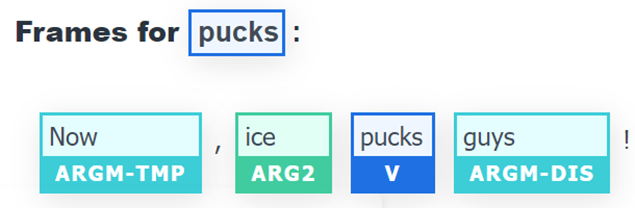

In [25]:
Image('https://github.com/Denis2054/Transformers-for-NLP-2nd-Edition/raw/main/Notebook%20images/10/B17948_10_19.png', width=800) #This is used for rendering images in the notebook